In [1]:
import pandas as pd
from optbinning import ContinuousOptimalBinning
import numpy as np


In [2]:
def create_woe_df(x, y, splits):
    # 1. Tạo các mốc bin từ -inf đến +inf
    bin_edges = [-np.inf] + list(splits) + [np.inf]
    
    # 2. Phân khoảng dữ liệu
    x_binned = pd.cut(x, bins=bin_edges, right=True)
    df = pd.DataFrame({'bin': x_binned, 'target': y})
    
    # 3. Thống kê số lượng Non-event (0) và Event (1) theo từng bin
    grouped = df.groupby('bin', observed=False)['target'].agg(
        n_events=lambda s: (s == 1).sum(),
        n_non_events=lambda s: (s == 0).sum()
    ).reset_index()
    
    # 4. Xử lý dữ liệu Missing (NaN) nếu có
    missing_mask = x.isna()
    if missing_mask.any():
        missing_row = pd.DataFrame({
            'bin': ['Missing'],
            'n_events': [(missing_mask & (y == 1)).sum()],
            'n_non_events': [(missing_mask & (y == 0)).sum()]
        })
        grouped = pd.concat([grouped, missing_row], ignore_index=True)
    
    # 5. Tính tỷ lệ % Event và % Non-Event
    total_events = (y == 1).sum()
    total_non_events = (y == 0).sum()
    
    grouped['pct_event'] = grouped['n_events'] / total_events
    grouped['pct_non_event'] = grouped['n_non_events'] / total_non_events
    
    # 6. Tính WOE và IV_detail (tránh lỗi chia cho 0 hoặc log(0))
    eps = 1e-6
    pct_event_adj = np.where(grouped['pct_event'] == 0, eps, grouped['pct_event'])
    pct_non_event_adj = np.where(grouped['pct_non_event'] == 0, eps, grouped['pct_non_event'])
    
    grouped['WOE'] = np.log(pct_non_event_adj / pct_event_adj)
    grouped['IV_detail'] = (pct_non_event_adj - pct_event_adj) * grouped['WOE']
    
    # 7. Tính IV_total
    grouped['IV_total'] = grouped['IV_detail'].sum()
    
    # Format kết quả đầu ra
    grouped['Bin'] = grouped['bin'].astype(str)
    return grouped[['Bin', 'WOE', 'IV_detail', 'IV_total']]

In [3]:
df = pd.read_csv('train_sdf_selected1.csv')
X_train = df.drop(columns=['LABEL'])
y = pd.Series(df['LABEL'].values, index=X_train.index)

In [4]:
df.columns

Index(['A', 'B', 'C', 'D', 'LABEL'], dtype='str')

## Nhập tên feature

In [5]:
feature = "A"

## Chỉnh số bin tối đa

In [6]:
max_bin = 10

In [7]:
x = X_train[feature].copy()
mask_nonmissing = x.notna()

x = x.loc[mask_nonmissing]
y = y.loc[mask_nonmissing]

n_old = len(X_train)
n_missing = X_train[feature].isna().sum()
n_new = mask_nonmissing.sum()  # or len(x)


Chỉnh ràng buộc min bin 5% thành % mới khi bỏ bin MISSING

In [8]:

# 2. Calculate 5% of old dataset as a percentage of the cleaned dataset
pct_of_new5 = (0.05 * n_old / n_new)
# pct_of_new50 = (0.50 * n_old / n_new)

print("Percentage of 0.05 on non-missing dataset:", pct_of_new5)

Percentage of 0.05 on non-missing dataset: 0.1539306220095694


## Thả tự do tối ưu (tối đa IV)

In [9]:
optb = ContinuousOptimalBinning(name=feature, dtype="numerical",
                    min_n_bins=4, 
                    max_n_bins=max_bin,
                    min_bin_size=pct_of_new5, max_bin_size=0.5,
                    monotonic_trend="auto"
                      )
optb.fit(x, y)


,name,'A'
,min_n_bins,4
,max_n_bins,10
,min_bin_size,np.float64(0.1539306220095694)
,max_bin_size,0.5
,dtype,'numerical'
,prebinning_method,'cart'
,max_n_prebins,20
,min_prebin_size,0.05
,monotonic_trend,'auto'
,min_mean_diff,0


In [10]:
print(optb.status)
print('Edge bins',optb.splits)

OPTIMAL
Edge bins [ 3.5 10.5 57.5]


In [11]:
optb.binning_table.build()

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV
0,"(-inf, 3.50)",3664,0.175311,7.0,0.043667,0.001910,0.0,1.0,3657,-0.001774,0.000311
1,"[3.50, 10.50)",3793,0.181483,5.0,0.036283,0.001318,0.0,1.0,3788,-0.002366,0.000429
2,"[10.50, 57.50)",8543,0.408756,25.0,0.054017,0.002926,0.0,1.0,8518,-0.000758,0.000310
3,"[57.50, inf)",4900,0.234450,40.0,0.089981,0.008163,0.0,1.0,4860,0.004479,0.001050
4,Special,0,0.000000,0.0,NaN,0.000000,NaN,NaN,0,-0.003684,0.000000
5,Missing,0,0.000000,0.0,NaN,0.000000,NaN,NaN,0,-0.003684,0.000000
Totals,,20900,1.000000,77.0,,0.003684,0.0,1.0,20823,0.016745,0.002100


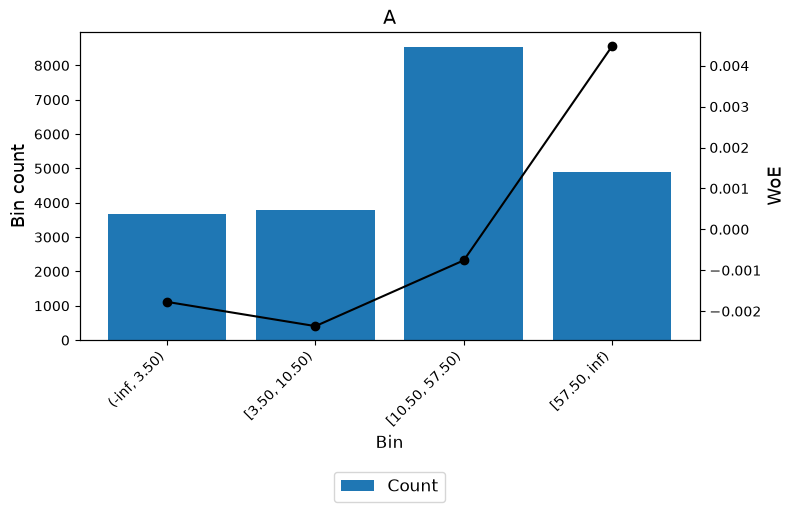

In [12]:
optb.binning_table.plot(metric="woe", show_bin_labels=True, figsize=(8,4), add_special=False, add_missing=False)


In [13]:
splits = optb.splits
woe_df = create_woe_df(x, y, splits)
woe_df

,Bin,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",0.658480,0.055783,0.424682
1,"(3.5, 10.5]",1.030148,0.120506,0.424682
2,"(10.5, 57.5]",0.231053,0.019499,0.424682
3,"(57.5, inf]",-0.800094,0.228895,0.424682


## Ép kiểu monotonic

In [14]:
optb = ContinuousOptimalBinning(name=feature, dtype="numerical",
                    min_n_bins=4, 
                    max_n_bins=max_bin,
                    min_bin_size=pct_of_new5, max_bin_size=0.5,
                    monotonic_trend="auto_asc_desc"
                      )
optb.fit(x, y)


,name,'A'
,min_n_bins,4
,max_n_bins,10
,min_bin_size,np.float64(0.1539306220095694)
,max_bin_size,0.5
,monotonic_trend,'auto_asc_desc'
,dtype,'numerical'
,prebinning_method,'cart'
,max_n_prebins,20
,min_prebin_size,0.05
,min_mean_diff,0


In [15]:
print('Status',optb.status)
print('Edge bins',optb.splits)

Status OPTIMAL
Edge bins [ 3.5 13.5 57.5]


In [16]:
optb.binning_table.build()

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV
0,"(-inf, 3.50)",3664,0.175311,7.0,0.043667,0.001910,0.0,1.0,3657,-0.001774,0.000311
1,"[3.50, 13.50)",4970,0.237799,12.0,0.049078,0.002414,0.0,1.0,4958,-0.001270,0.000302
2,"[13.50, 57.50)",7366,0.352440,18.0,0.049373,0.002444,0.0,1.0,7348,-0.001241,0.000437
3,"[57.50, inf)",4900,0.234450,40.0,0.089981,0.008163,0.0,1.0,4860,0.004479,0.001050
4,Special,0,0.000000,0.0,NaN,0.000000,NaN,NaN,0,-0.003684,0.000000
5,Missing,0,0.000000,0.0,NaN,0.000000,NaN,NaN,0,-0.003684,0.000000
Totals,,20900,1.000000,77.0,,0.003684,0.0,1.0,20823,0.016131,0.002100


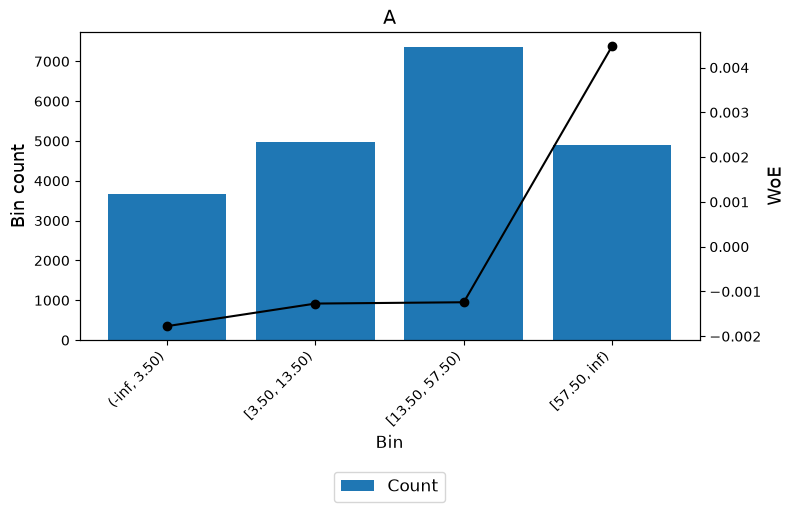

In [17]:
optb.binning_table.plot(metric="woe", show_bin_labels=True, figsize=(8,4), add_special=False, add_missing=False)

In [18]:
splits = optb.splits
woe_df = create_woe_df(x, y, splits)
woe_df

,Bin,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",0.658480,0.055783,0.368593
1,"(3.5, 13.5]",0.423843,0.034864,0.368593
2,"(13.5, 57.5]",0.411804,0.049051,0.368593
3,"(57.5, inf]",-0.800094,0.228895,0.368593


## Ép kiểu U-shape

In [19]:
optb = ContinuousOptimalBinning(name=feature, dtype="numerical",
                    min_n_bins=4, 
                    max_n_bins=max_bin,
                    min_bin_size=pct_of_new5, max_bin_size=0.5,
                    monotonic_trend="auto_heuristic"
                      )
optb.fit(x, y)


,name,'A'
,min_n_bins,4
,max_n_bins,10
,min_bin_size,np.float64(0.1539306220095694)
,max_bin_size,0.5
,monotonic_trend,'auto_heuristic'
,dtype,'numerical'
,prebinning_method,'cart'
,max_n_prebins,20
,min_prebin_size,0.05
,min_mean_diff,0


In [20]:
print(optb.status)
print('Edge bins',optb.splits)

OPTIMAL
Edge bins [ 3.5 10.5 57.5]


In [21]:
optb.binning_table.build()

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV
0,"(-inf, 3.50)",3664,0.175311,7.0,0.043667,0.001910,0.0,1.0,3657,-0.001774,0.000311
1,"[3.50, 10.50)",3793,0.181483,5.0,0.036283,0.001318,0.0,1.0,3788,-0.002366,0.000429
2,"[10.50, 57.50)",8543,0.408756,25.0,0.054017,0.002926,0.0,1.0,8518,-0.000758,0.000310
3,"[57.50, inf)",4900,0.234450,40.0,0.089981,0.008163,0.0,1.0,4860,0.004479,0.001050
4,Special,0,0.000000,0.0,NaN,0.000000,NaN,NaN,0,-0.003684,0.000000
5,Missing,0,0.000000,0.0,NaN,0.000000,NaN,NaN,0,-0.003684,0.000000
Totals,,20900,1.000000,77.0,,0.003684,0.0,1.0,20823,0.016745,0.002100


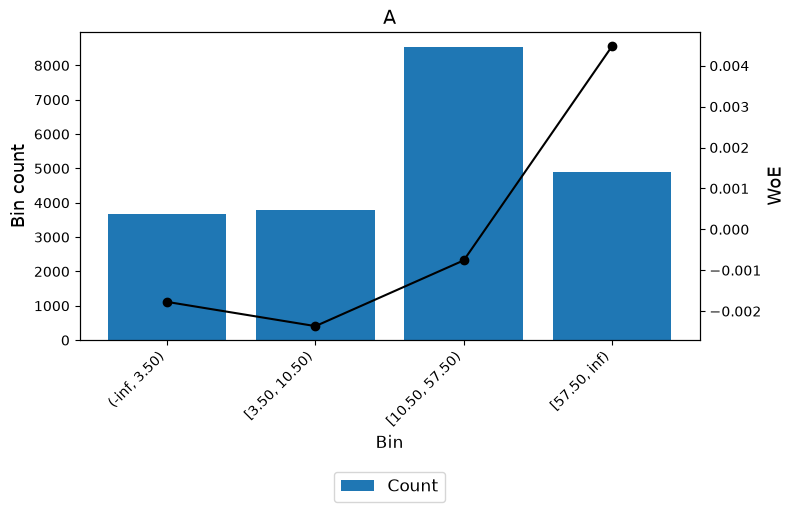

In [22]:
optb.binning_table.plot(metric="woe", show_bin_labels=True, figsize=(8,4), add_special=False, add_missing=False)

In [23]:
splits = optb.splits
woe_df = create_woe_df(x, y, splits)
woe_df

,Bin,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",0.658480,0.055783,0.424682
1,"(3.5, 10.5]",1.030148,0.120506,0.424682
2,"(10.5, 57.5]",0.231053,0.019499,0.424682
3,"(57.5, inf]",-0.800094,0.228895,0.424682
